
# Text Visualization Lab -- NLTK Movie Reviews

**Dataset:** [NLTK Movie Review Polarity Dataset] - ~2,000 movie reviews labeled as *pos* or *neg*  




## Preprocessing



In [12]:

import re

stopwords = {
    "the","and","a","an","is","was","were","to","for","of","in","by","on","at","it","as",
    "i","you","he","she","we","they","that","this","be","or","are","not","have","has","had",
    "but","with","from","so","there","about","before","after","ever","do","does","did",
    "would","could","should","than","then","also","very","one","two","can","just"
}

def tokenize(text: str):
    text = text.lower()
    tokens = re.split(r"[^a-z']+", text)
    return [t for t in tokens if t and t not in stopwords]

tokens_per_doc = [tokenize(t) for t in df["text"].tolist()]
all_tokens = [t for doc in tokens_per_doc for t in doc]
len(all_tokens)


822607


## Visualization 1 -- Top Words in Positive vs Negative Reviews

**Figure(s):** Two bar charts of the top 20 content words for `pos` and `neg`.  
**Interpretation:** Comparing tall bars across the two charts highlights vocabulary differences that often signal sentiment.


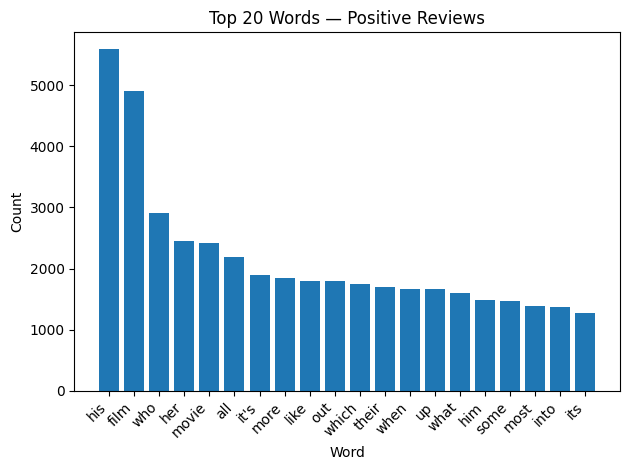

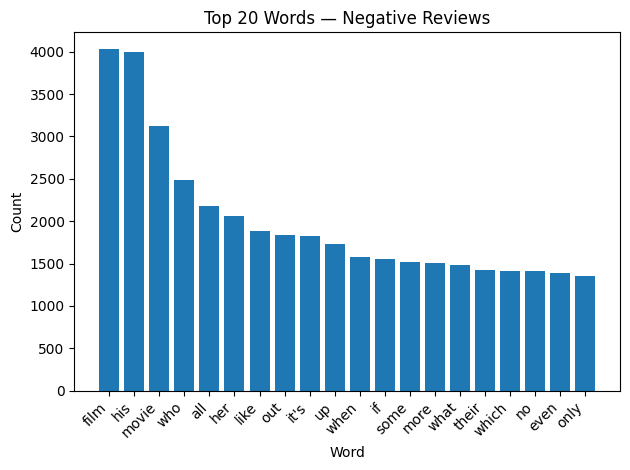

In [13]:

import matplotlib.pyplot as plt
from collections import Counter

pos_tokens = [t for toks, lbl in zip(tokens_per_doc, df["label"]) if lbl == "pos" for t in toks]
neg_tokens = [t for toks, lbl in zip(tokens_per_doc, df["label"]) if lbl == "neg" for t in toks]

pos_top = Counter(pos_tokens).most_common(20)
neg_top = Counter(neg_tokens).most_common(20)

# Positive
labels_pos = [w for w,_ in pos_top]
values_pos = [c for _,c in pos_top]
plt.figure()
plt.bar(range(len(values_pos)), values_pos)
plt.xticks(range(len(values_pos)), labels_pos, rotation=45, ha='right')
plt.title('Top 20 Words — Positive Reviews')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Negative
labels_neg = [w for w,_ in neg_top]
values_neg = [c for _,c in neg_top]
plt.figure()
plt.bar(range(len(values_neg)), values_neg)
plt.xticks(range(len(values_neg)), labels_neg, rotation=45, ha='right')
plt.title('Top 20 Words — Negative Reviews')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## Visualization 2 -- Most Frequent Bigrams 

**Figure:** Horizontal bar chart of the top 20 bigrams across all reviews.  
**Interpretation:** Frequent two-word phrases (e.g., "well worth", "not even", "special effects") reveal common expressions and pairings that can hint at sentiment or topics.


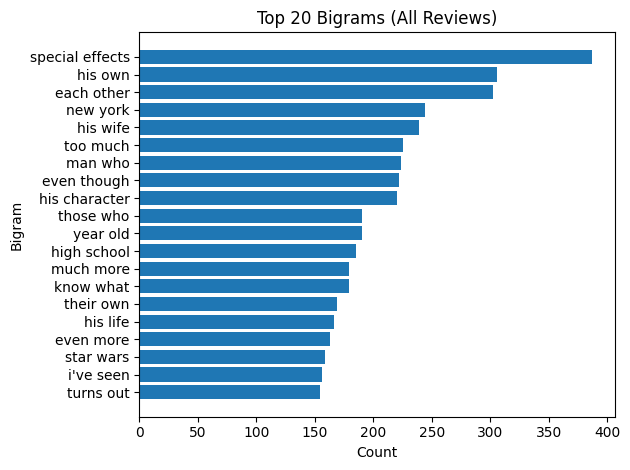

In [14]:

from itertools import tee

def bigrams(seq):
    a, b = tee(seq)
    next(b, None)
    return list(zip(a, b))

all_bigrams = [bg for doc in tokens_per_doc for bg in bigrams(doc)]
bigram_counts = Counter(all_bigrams)
top_bigrams = bigram_counts.most_common(20)

labels_bg = [f"{a} {b}" for (a,b),_ in top_bigrams][::-1]
values_bg = [c for _,c in top_bigrams][::-1]

plt.figure()
plt.barh(range(len(values_bg)), values_bg)
plt.yticks(range(len(values_bg)), labels_bg)
plt.title('Top 20 Bigrams (All Reviews)')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()



## Visualization 3 -- VADER Sentiment Distribution by Label

**Method:** Use NLTK's VADER sentiment analyzer on each review. We plot simple boxplots of the compound score for positive vs negative labels.  
**Interpretation:** The positive class should skew higher and the negative class lower; any overlap reflects the subtlety of natural language and lexicon limitations.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Stephen\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


<Figure size 640x480 with 0 Axes>

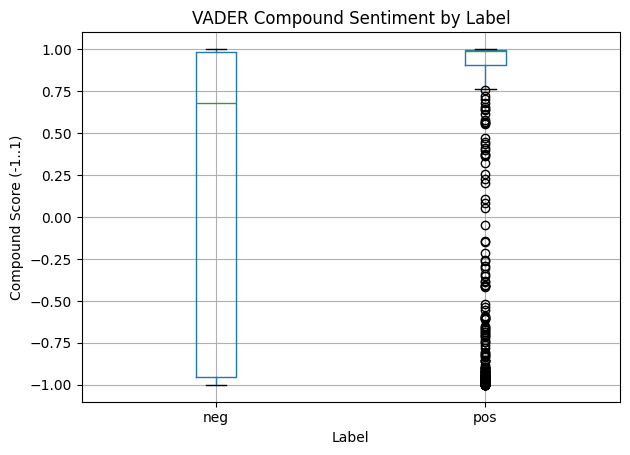

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
neg,1000.0,0.107110,0.904130,-0.9997,-0.95455,0.68205,0.982025,0.9996
pos,1000.0,0.646057,0.702314,-0.9996,0.90290,0.99090,0.997225,0.9999


In [15]:

# Ensure VADER is available
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

scores = [sia.polarity_scores(txt)["compound"] for txt in df["text"]]
df_scores = pd.DataFrame({"label": df["label"], "compound": scores})

# Boxplot of compound by label
plt.figure()
df_scores.boxplot(column="compound", by="label")
plt.title("VADER Compound Sentiment by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Compound Score (-1..1)")
plt.tight_layout()
plt.show()

df_scores.groupby("label")["compound"].describe()



---

### Notes & Citation
- **Dataset:** NLTK Movie Reviews Corpus (Pang & Lee, 2004). Distributed via the NLTK library for educational/research use.  
- **Preprocessing:** lowercase, regex tokenization, small stopword list.  
- **Sentiment:** VADER (lexicon-based) scores are illustrative; not a benchmark model.


